In [6]:
import numpy as np
from scipy.stats import ks_2samp
from scipy import stats
import matplotlib.pyplot as plt
import h5py
import sys
sys.path.append('../../py_files/')
sys.path.append('/home/pranavsatheesh/arepo_package/')
#import weights
import control_sample as control
import arepo_package as arepo
from tqdm import tqdm
import os

import host_galaxy_enhancement_plots as hostplot
import host_utils as hostutils

tex_path = '/apps/texlive/2023/bin/x86_64-linux/'
os.environ['PATH'] += os.pathsep + tex_path

import scienceplots
plt.style.use('science')

In [2]:
pop_file_path = '/home/pranavsatheesh/host_galaxies/data/population_files/' 
tng_pop_file_path = '/home/pranavsatheesh/host_galaxies/data/population_files/'

TNG_basepath = '/orange/lblecha/IllustrisTNG/Runs/TNG50-1/output'
TNG_50_pop = control.load_pop_file(TNG_basepath,tng_pop_file_path,[0,0,1000,1])
TNG_50_control = control.control_samples_TNG(TNG_50_pop,max_Mstar_tolerance=0.15,max_z_tolerance=0.1)
TNG_color = '#d95f02'

finding controls: 100%|██████████| 504/504 [00:01<00:00, 346.50it/s]
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:398: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_pop = self.Mdot_control_pop/self.MBH_control_pop


Number of available mergers in this population is 504
Number of cases where a close enough match is not found within the acceptable tolerance: 16


In [53]:
brahma_basepath="/orange/lblecha/aklantbhowmick/GAS_BASED_SEED_MODEL_UNIFORM_RUNS/L12p5n512/AREPO/"
brahma_simName_array = ['SM5_TNG','SM5_LW10_TNG','SM5_DFD_3_TNG','SM5_LW10_DFD_3_TNG','SM5_LW10_LOWSPIN_TNG','SM5_LW10_LOWSPIN_RICH_TNG']
brahma_sim_colors = {
    brahma_simName_array[0]: '#bdc9e1', 
    brahma_simName_array[1]: '#67a9cf', 
    brahma_simName_array[2]: '#1c9099', 
    brahma_simName_array[3]: '#016c59',
    brahma_simName_array[4]: '#3690c0',
    brahma_simName_array[5]: '#02818a'
}
brahma_sim_obj = {}
brahma_sim_zbins = {}
#brahma_sim_zbin_width = {}
for i,sim in enumerate(brahma_simName_array):
    simPath = brahma_basepath + sim + '/'
    brahma_pop_Nstar10 = control.load_pop_file(simPath,pop_file_path,[10,10,10,1])
    if brahma_simName_array[i] == 'SM5_LW10_LOWSPIN_RICH_TNG':
        brahma_control = control.control_sample_brahma(brahma_pop_Nstar10,max_Mstar_tolerance=0.6,max_z_tolerance=0.2)
    else:
        brahma_control = control.control_sample_brahma(brahma_pop_Nstar10,max_Mstar_tolerance=0.15,max_z_tolerance=0.2)
    brahma_sim_obj[sim] = brahma_control
    #brahma_sim_zbin_width,brahma_sim_zbins[sim] =hostplot.find_best_z_width(brahma_control.z_merging_pop,z_min=0,z_max=10,z_width_initial=0.2)
    brahma_sim_zbins[sim] = hostplot.find_adaptive_z_bins(brahma_control.z_merging_pop,z_min=0,z_max=12,zbin_width=0.3,min_N_values=10)
    print(sim,brahma_sim_zbins[sim])

finding controls: 100%|██████████| 773/773 [00:00<00:00, 21908.51it/s]
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:691: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_pop = self.Mdot_control_pop/self.MBH_control_pop
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:695: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_massive_pop = self.Mdot_massive_control_pop/self.MBH_massive_control_pop
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:698: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_luminous_pop = self.Mdot_luminous_control_pop/self.MBH_luminous_control_pop


Number of cases where a close enough match is not found within the acceptable tolerance: 172
number of processable mergers with valid controls:
581
[31, 40, 44, 65, 68, 83, 62, 39, 25, 13]
SM5_TNG [0.  0.3 0.6 0.9 1.2 1.5 2.1 3.1 4.1 5.1 6.1]


finding controls: 100%|██████████| 645/645 [00:00<00:00, 24860.33it/s]


Number of cases where a close enough match is not found within the acceptable tolerance: 148
number of processable mergers with valid controls:
486
[26, 29, 41, 48, 50, 71, 56, 44, 22, 14]
SM5_LW10_TNG [0.  0.3 0.6 0.9 1.2 1.5 2.1 3.1 4.1 5.1 6.1]


finding controls:   0%|          | 0/899 [00:00<?, ?it/s]

...

Number of cases where a close enough match is not found within the acceptable tolerance: 228
number of processable mergers with valid controls:
574
[40, 36, 51, 55, 62, 79, 78, 49, 18, 11]
SM5_LW10_DFD_3_TNG [0.  0.3 0.6 0.9 1.2 1.5 2.1 3.1 4.1 5.1 6.1]


finding controls: 100%|██████████| 488/488 [00:00<00:00, 26261.15it/s]


Number of cases where a close enough match is not found within the acceptable tolerance: 123
number of processable mergers with valid controls:
356
[27, 21, 21, 35, 28, 58, 45, 26, 24, 16, 10]
SM5_LW10_LOWSPIN_TNG [0.  0.3 0.6 0.9 1.2 1.5 2.1 3.1 4.1 5.1 6.1 8.1]


finding controls: 100%|██████████| 175/175 [00:00<00:00, 25043.61it/s]

Number of cases where a close enough match is not found within the acceptable tolerance: 25
number of processable mergers with valid controls:
149
[11, 12, 25, 20, 11, 11, 12, 10]
SM5_LW10_LOWSPIN_RICH_TNG [0.  0.3 0.8 1.5 2.2 3.1 4.1 5.1 7.1]


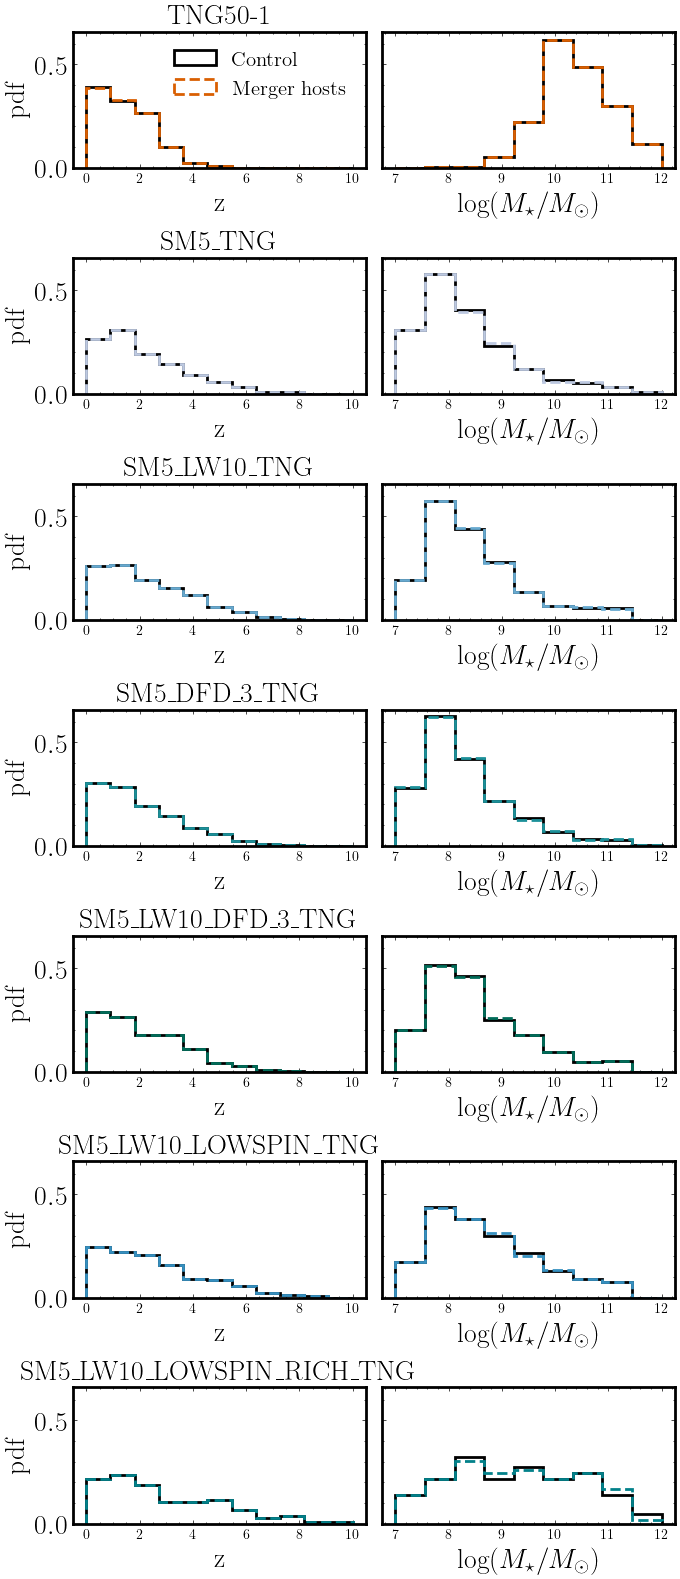

In [57]:
fig, axes = plt.subplots(7,2,figsize=(7,16),sharey=True)
hostplot.set_plot_style(linewidth=2,spinewidth=2, titlesize=20,labelsize=20,xlabelsize=10,ylabelsize=20,legendsize=15)
flattened_axes = axes.flatten()

axes_plt = hostplot.match_z_Mstar_plot([axes[0][0],axes[0][1]],TNG_50_control,sim_color=TNG_color,Mstar_binsize = 0.5,Mstar_min = 7,Mstar_max = 12,z_binsize = 0.8,z_min = 0,z_max = 10)
axes_plt[0].set_title("TNG50-1")
axes_plt[0].set_xlabel("z")
axes_plt[0].set_ylabel("pdf")
axes_plt[1].set_xlabel("$\log(M_{\star}/M_{\odot})$")

for i,sim in enumerate(brahma_simName_array):
    ax_plt = [axes[i+1][0],axes[i+1][1]]
    axes_plt = hostplot.match_z_Mstar_plot(ax_plt,brahma_sim_obj[sim],sim_color=brahma_sim_colors[sim],Mstar_binsize = 0.5,Mstar_min = 7,Mstar_max = 12,z_binsize = 0.8,z_min = 0,z_max = 10)
    axes_plt[0].set_title(sim)
    axes_plt[0].set_xlabel("z")
    axes_plt[0].set_ylabel("pdf")
    axes_plt[1].set_xlabel("$\log(M_{\star}/M_{\odot})$")

axes[0,0].legend()
fig.tight_layout()
fig.savefig('../../figures/matching_z_Mstar_distributions_controls_vs_mergers_sims.pdf')

In [58]:
# Calculate KS and Hellinger statistics for all simulations
sim_objs = {'TNG50': TNG_50_control}
sim_objs.update(brahma_sim_obj)
sim_names = ['TNG50'] + brahma_simName_array

# Calculate statistics
stats_results = hostutils.calculate_ks_hellinger_statistics(sim_objs, sim_names)

# Print summary
hostutils.print_ks_hellinger_summary(stats_results)

Simulation                     HD(z)      KS(z)      p(z)         HD(Mstar)    KS(Mstar)    p(Mstar)    
--------------------------------------------------------------------------------------------------------------
TNG50                          0.0565     0.0149     1.000e+00    0.0501       0.0064       1.000e+00   
SM5_TNG                        0.0770     0.0461     6.913e-01    0.0375       0.0084       1.000e+00   
SM5_LW10_TNG                   0.0735     0.0442     8.216e-01    0.0649       0.0147       1.000e+00   
SM5_DFD_3_TNG                  0.0832     0.0559     3.721e-01    0.0317       0.0093       1.000e+00   
SM5_LW10_DFD_3_TNG             0.0617     0.0413     8.036e-01    0.0362       0.0083       1.000e+00   
SM5_LW10_LOWSPIN_TNG           0.0643     0.0351     9.906e-01    0.0408       0.0192       1.000e+00   
SM5_LW10_LOWSPIN_RICH_TNG      0.0244     0.0254     1.000e+00    0.1181       0.0339       1.000e+00   
